This notebook contains all models built for this project


The following regression models will be built for this project:
- Linear Regression (Multiple, Lasso, Ridge, Elastic net)
- Regression Trees/ Random Forest Regression
- XGBoost Regression

In [78]:
# Import libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from statsmodels.api import OLS
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNetCV
import seaborn as sns
from sklearn.metrics import PredictionErrorDisplay

In [79]:
# Read in the data
players = pd.read_csv(r'../Data/final_player_data.csv')

# Graphing potential predictors with the target

Before modeling, we need to analyze the relationships with the target and potential predictors. This will allow us to see if a linear regression model will be a fit.

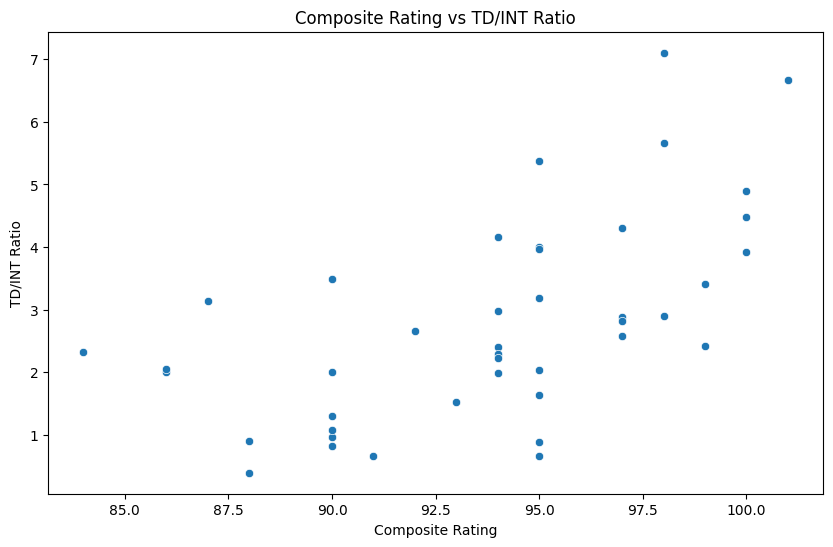

In [80]:
# Examine scout rating vs TD/int ratio
plt.figure(figsize=(10, 6))
sns.scatterplot(x='composite_rating', y='TD/INT_Ratio_player_after_enrollment', data=players)
plt.title('Composite Rating vs TD/INT Ratio')
plt.xlabel('Composite Rating')
plt.ylabel('TD/INT Ratio')
plt.show()

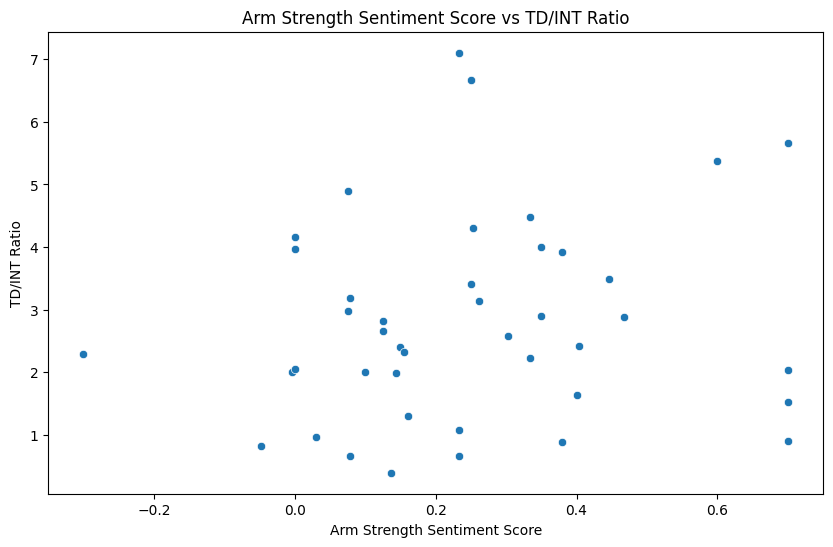

In [81]:
# Examine Arm_Strength_sentiment_score vs TD/int ratio
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Arm_Strength_sentiment_score', y='TD/INT_Ratio_player_after_enrollment', data=players)
plt.title('Arm Strength Sentiment Score vs TD/INT Ratio')
plt.xlabel('Arm Strength Sentiment Score')
plt.ylabel('TD/INT Ratio')
plt.show()

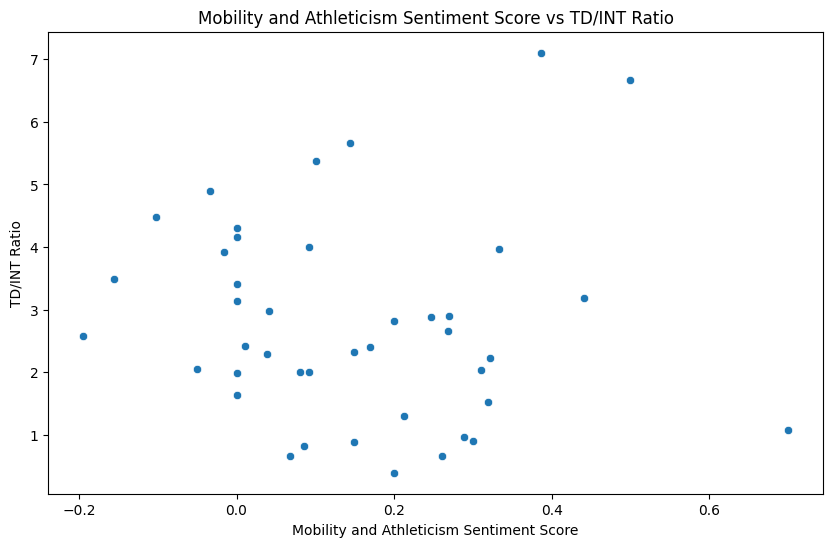

In [82]:
# Examine Mobility_and_Athleticism_sentiment_score vs TD/int ratio
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Mobility_and_Athleticism_sentiment_score', y='TD/INT_Ratio_player_after_enrollment', data=players)
plt.title('Mobility and Athleticism Sentiment Score vs TD/INT Ratio')
plt.xlabel('Mobility and Athleticism Sentiment Score')
plt.ylabel('TD/INT Ratio')
plt.show()

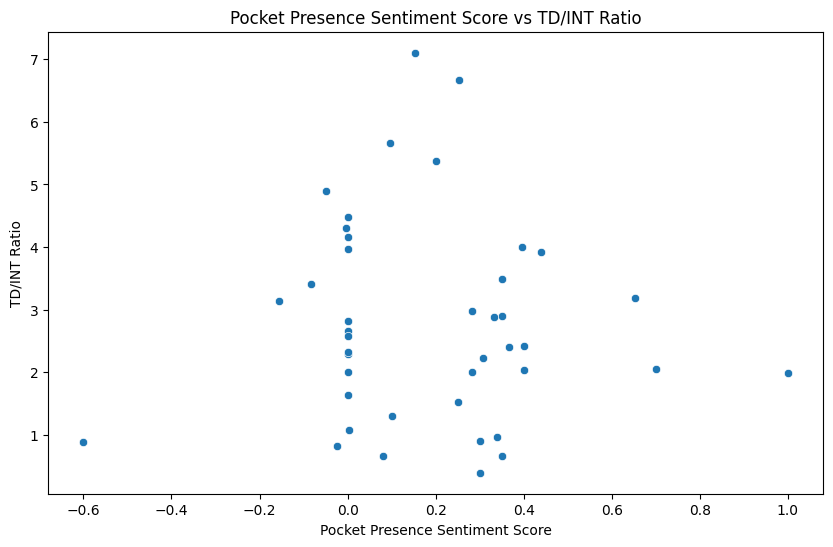

In [83]:
# Examine Pocket_Presence_sentiment_score vs TD/int ratio
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Pocket_Presence_sentiment_score', y='TD/INT_Ratio_player_after_enrollment', data=players)
plt.title('Pocket Presence Sentiment Score vs TD/INT Ratio')
plt.xlabel('Pocket Presence Sentiment Score')
plt.ylabel('TD/INT Ratio')
plt.show()

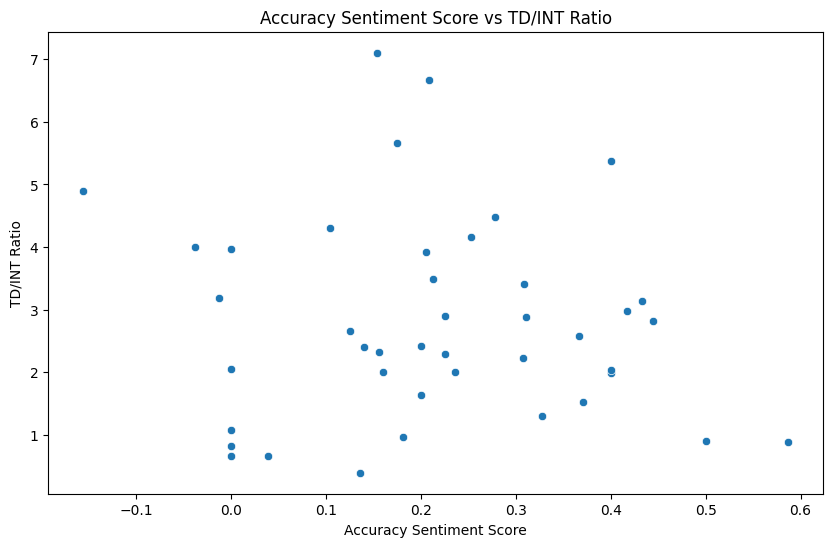

In [84]:
# Examine Accuracy_sentiment_score vs TD/int ratio
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Accuracy_sentiment_score', y='TD/INT_Ratio_player_after_enrollment', data=players)
plt.title('Accuracy Sentiment Score vs TD/INT Ratio')
plt.xlabel('Accuracy Sentiment Score')
plt.ylabel('TD/INT Ratio')
plt.show()

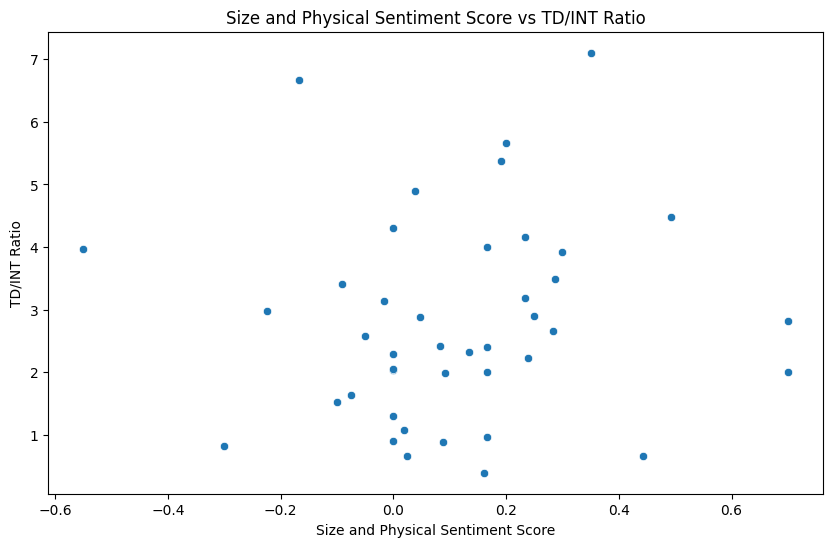

In [85]:
# Examine Size_and_Physical_sentiment_score vs TD/int ratio
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Size_and_Physical_sentiment_score', y='TD/INT_Ratio_player_after_enrollment', data=players)
plt.title('Size and Physical Sentiment Score vs TD/INT Ratio')
plt.xlabel('Size and Physical Sentiment Score')
plt.ylabel('TD/INT Ratio')
plt.show()

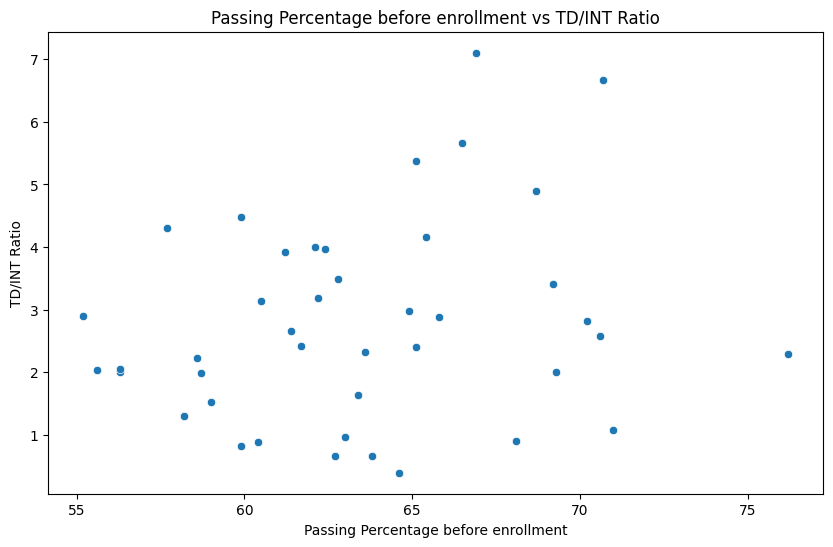

In [86]:
# Examine Passing percentage before enrollment vs TD/int ratio
plt.figure(figsize=(10, 6))
sns.scatterplot(x='passing_pct_team_before_enrollment', y='TD/INT_Ratio_player_after_enrollment', data=players)
plt.title('Passing Percentage before enrollment vs TD/INT Ratio')
plt.xlabel('Passing Percentage before enrollment')
plt.ylabel('TD/INT Ratio')
plt.show()

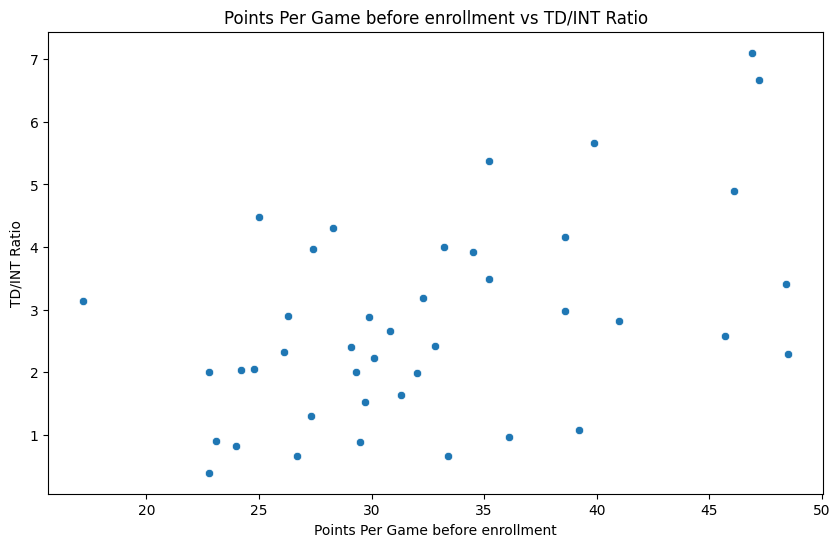

In [87]:
# Examine Points Per Game before enrollment vs TD/int ratio
plt.figure(figsize=(10, 6))
sns.scatterplot(x='ppg_offense_team_before_enrollment', y='TD/INT_Ratio_player_after_enrollment', data=players)
plt.title('Points Per Game before enrollment vs TD/INT Ratio')
plt.xlabel('Points Per Game before enrollment')
plt.ylabel('TD/INT Ratio')
plt.show()

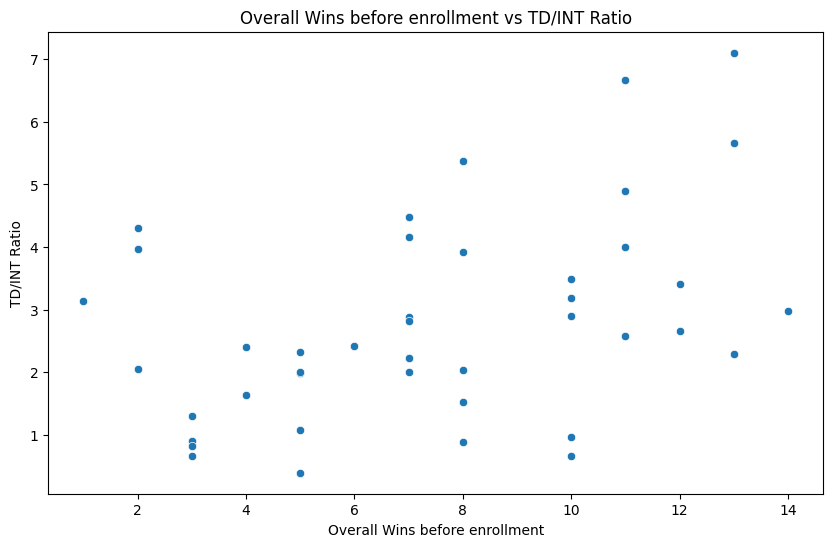

In [88]:
# Examine Overall Wins before enrollment vs TD/int ratio
plt.figure(figsize=(10, 6))
sns.scatterplot(x='overall_wins_team_before_enrollment', y='TD/INT_Ratio_player_after_enrollment', data=players)
plt.title('Overall Wins before enrollment vs TD/INT Ratio')
plt.xlabel('Overall Wins before enrollment')
plt.ylabel('TD/INT Ratio')
plt.show()

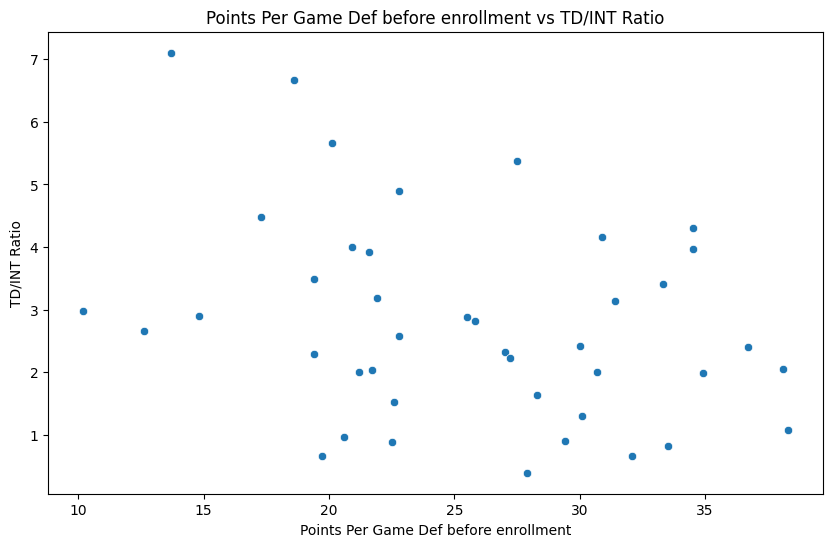

In [89]:
# Examine Points Per Game def before enrollment vs TD/int ratio
plt.figure(figsize=(10, 6))
sns.scatterplot(x='ppg_defense_team_before_enrollment', y='TD/INT_Ratio_player_after_enrollment', data=players)
plt.title('Points Per Game Def before enrollment vs TD/INT Ratio')
plt.xlabel('Points Per Game Def before enrollment')
plt.ylabel('TD/INT Ratio')
plt.show()

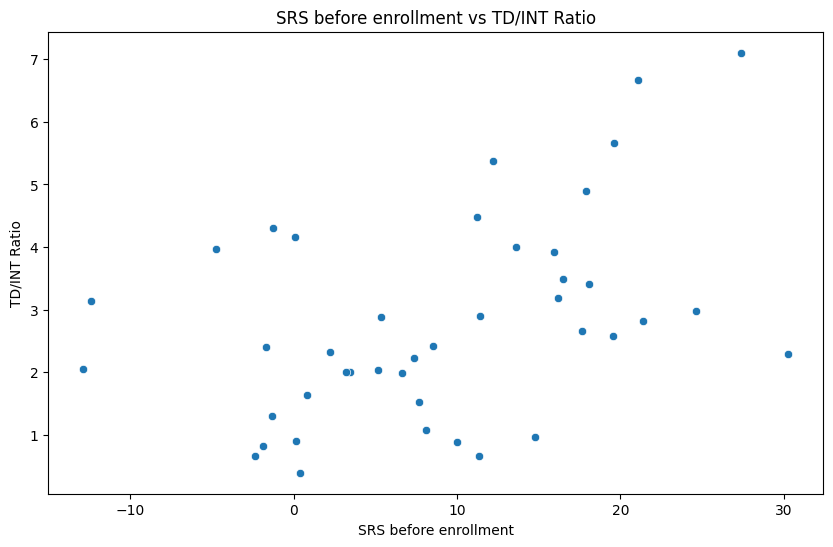

In [90]:
# Examine SRS before enrollment vs TD/int ratio
plt.figure(figsize=(10, 6))
sns.scatterplot(x='srs_team_before_enrollment', y='TD/INT_Ratio_player_after_enrollment', data=players)
plt.title('SRS before enrollment vs TD/INT Ratio')
plt.xlabel('SRS before enrollment')
plt.ylabel('TD/INT Ratio')
plt.show()

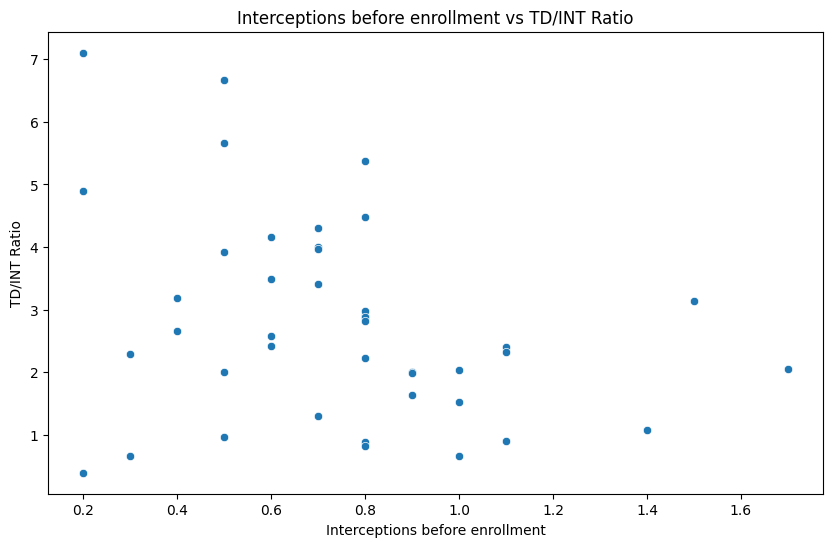

In [91]:
# Examine Interceptions before enrollment vs TD/int ratio
plt.figure(figsize=(10, 6))
sns.scatterplot(x='interceptions_team_before_enrollment', y='TD/INT_Ratio_player_after_enrollment', data=players)
plt.title('Interceptions before enrollment vs TD/INT Ratio')
plt.xlabel('Interceptions before enrollment')
plt.ylabel('TD/INT Ratio')
plt.show()

The following look like they be important for linear regression modeling: 

- 'interceptions_team_before_enrollment'
- 'srs_team_before_enrollment'
- 'overall_wins_team_before_enrollment'
- 'ppg_offense_team_before_enrollment'
- 'composite_rating'

In [92]:
players.columns

Index(['player', 'url', 'recruiting_rank', 'height', 'weight',
       'composite_rating', 'high_school', 'city', 'state', 'draft_projection',
       'reminds_of', 'evaluated_date', 'analyst', 'athletic_background',
       'committed_school', 'numerical_rating', 'Is_FBS', 'Is_SEC',
       'Is_Big_Ten', 'Is_Big_XII', 'Is_ACC', 'pos_DUAL', 'pos_PRO', 'pos_QB',
       'star_2', 'star_3', 'star_4', 'star_5', 'Is_Top_Five_Ranked',
       'Is_From_East', 'Is_From_West', 'weight_to_height_ratio', 'bmi',
       'Accuracy_sentiment_score', 'Arm_Strength_sentiment_score',
       'Mobility_and_Athleticism_sentiment_score',
       'NFL_Draft_Projection_sentiment_score',
       'Pocket_Presence_sentiment_score', 'Size_and_Physical_sentiment_score',
       'games_played_player_after_enrollment',
       'completions_player_after_enrollment',
       'attempts_player_after_enrollment',
       'completion_pct_player_after_enrollment',
       'yards_player_after_enrollment', 'touchdowns_player_after_enrol

## Setting up for modeling:

Target: 'TD/INT_Ratio_player_after_enrollment'

_Predictors_ - Certain predictors such as player stats cannot be used as there would be data leakage and other variables have missingness or may not be useful for modeling purposes. From this, here is the list of predictors that will be used in modeling:

['recruiting_rank',
 'height',
 'weight',
 'composite_rating',
 'Is_FBS',
 'Is_SEC',
 'Is_Big_Ten',
 'Is_Big_XII',
 'Is_ACC',
 'pos_DUAL',
 'pos_PRO',
 'pos_QB',
 'star_2',
 'star_3',
 'star_4',
 'star_5',
 'Is_Top_Five_Ranked',
 'Is_From_East',
 'Is_From_West',
 'weight_to_height_ratio',
 'bmi',
 'Accuracy_sentiment_score',
 'Arm_Strength_sentiment_score',
 'Mobility_and_Athleticism_sentiment_score',
 'NFL_Draft_Projection_sentiment_score',
 'Pocket_Presence_sentiment_score',
 'Size_and_Physical_sentiment_score',
 'games_played_team_before_enrollment',
       'ppg_team_before_enrollment',
       'passing_completions_team_before_enrollment',
       'passing_attempts_team_before_enrollment',
       'passing_pct_team_before_enrollment',
       'passing_yards_team_before_enrollment',
       'passing_touchdowns_team_before_enrollment',
       'rushing_attempts_team_before_enrollment',
       'rushing_yards_team_before_enrollment',
       'rushing_average_team_before_enrollment',
       'rushing_touchdowns_team_before_enrollment',
       'offensive_plays_team_before_enrollment',
       'offensive_yards_team_before_enrollment',
       'offensive_average_team_before_enrollment',
       'first_down_passes_team_before_enrollment',
       'first_down_rushes_team_before_enrollment',
       'first_down_penalties_team_before_enrollment',
       'first_downs_team_before_enrollment',
       'penalty_counts_team_before_enrollment',
       'penalty_yards_team_before_enrollment',
       'fumbles_team_before_enrollment',
       'interceptions_team_before_enrollment',
       'total_turnovers_team_before_enrollment',
       'overall_wins_team_before_enrollment',
       'overall_losses_team_before_enrollment',
       'overall_win_pct_team_before_enrollment',
       'conference_wins_team_before_enrollment',
       'conference_losses_team_before_enrollment',
       'conference_win_pct_team_before_enrollment',
       'ppg_offense_team_before_enrollment',
       'ppg_defense_team_before_enrollment', 
       'srs_team_before_enrollment',
       'sos_team_before_enrollment',
       'final_ranking_team_AP_top_10_before_enrollment',
       'highest_ranking_team_AP_top_10_before_enrollment']

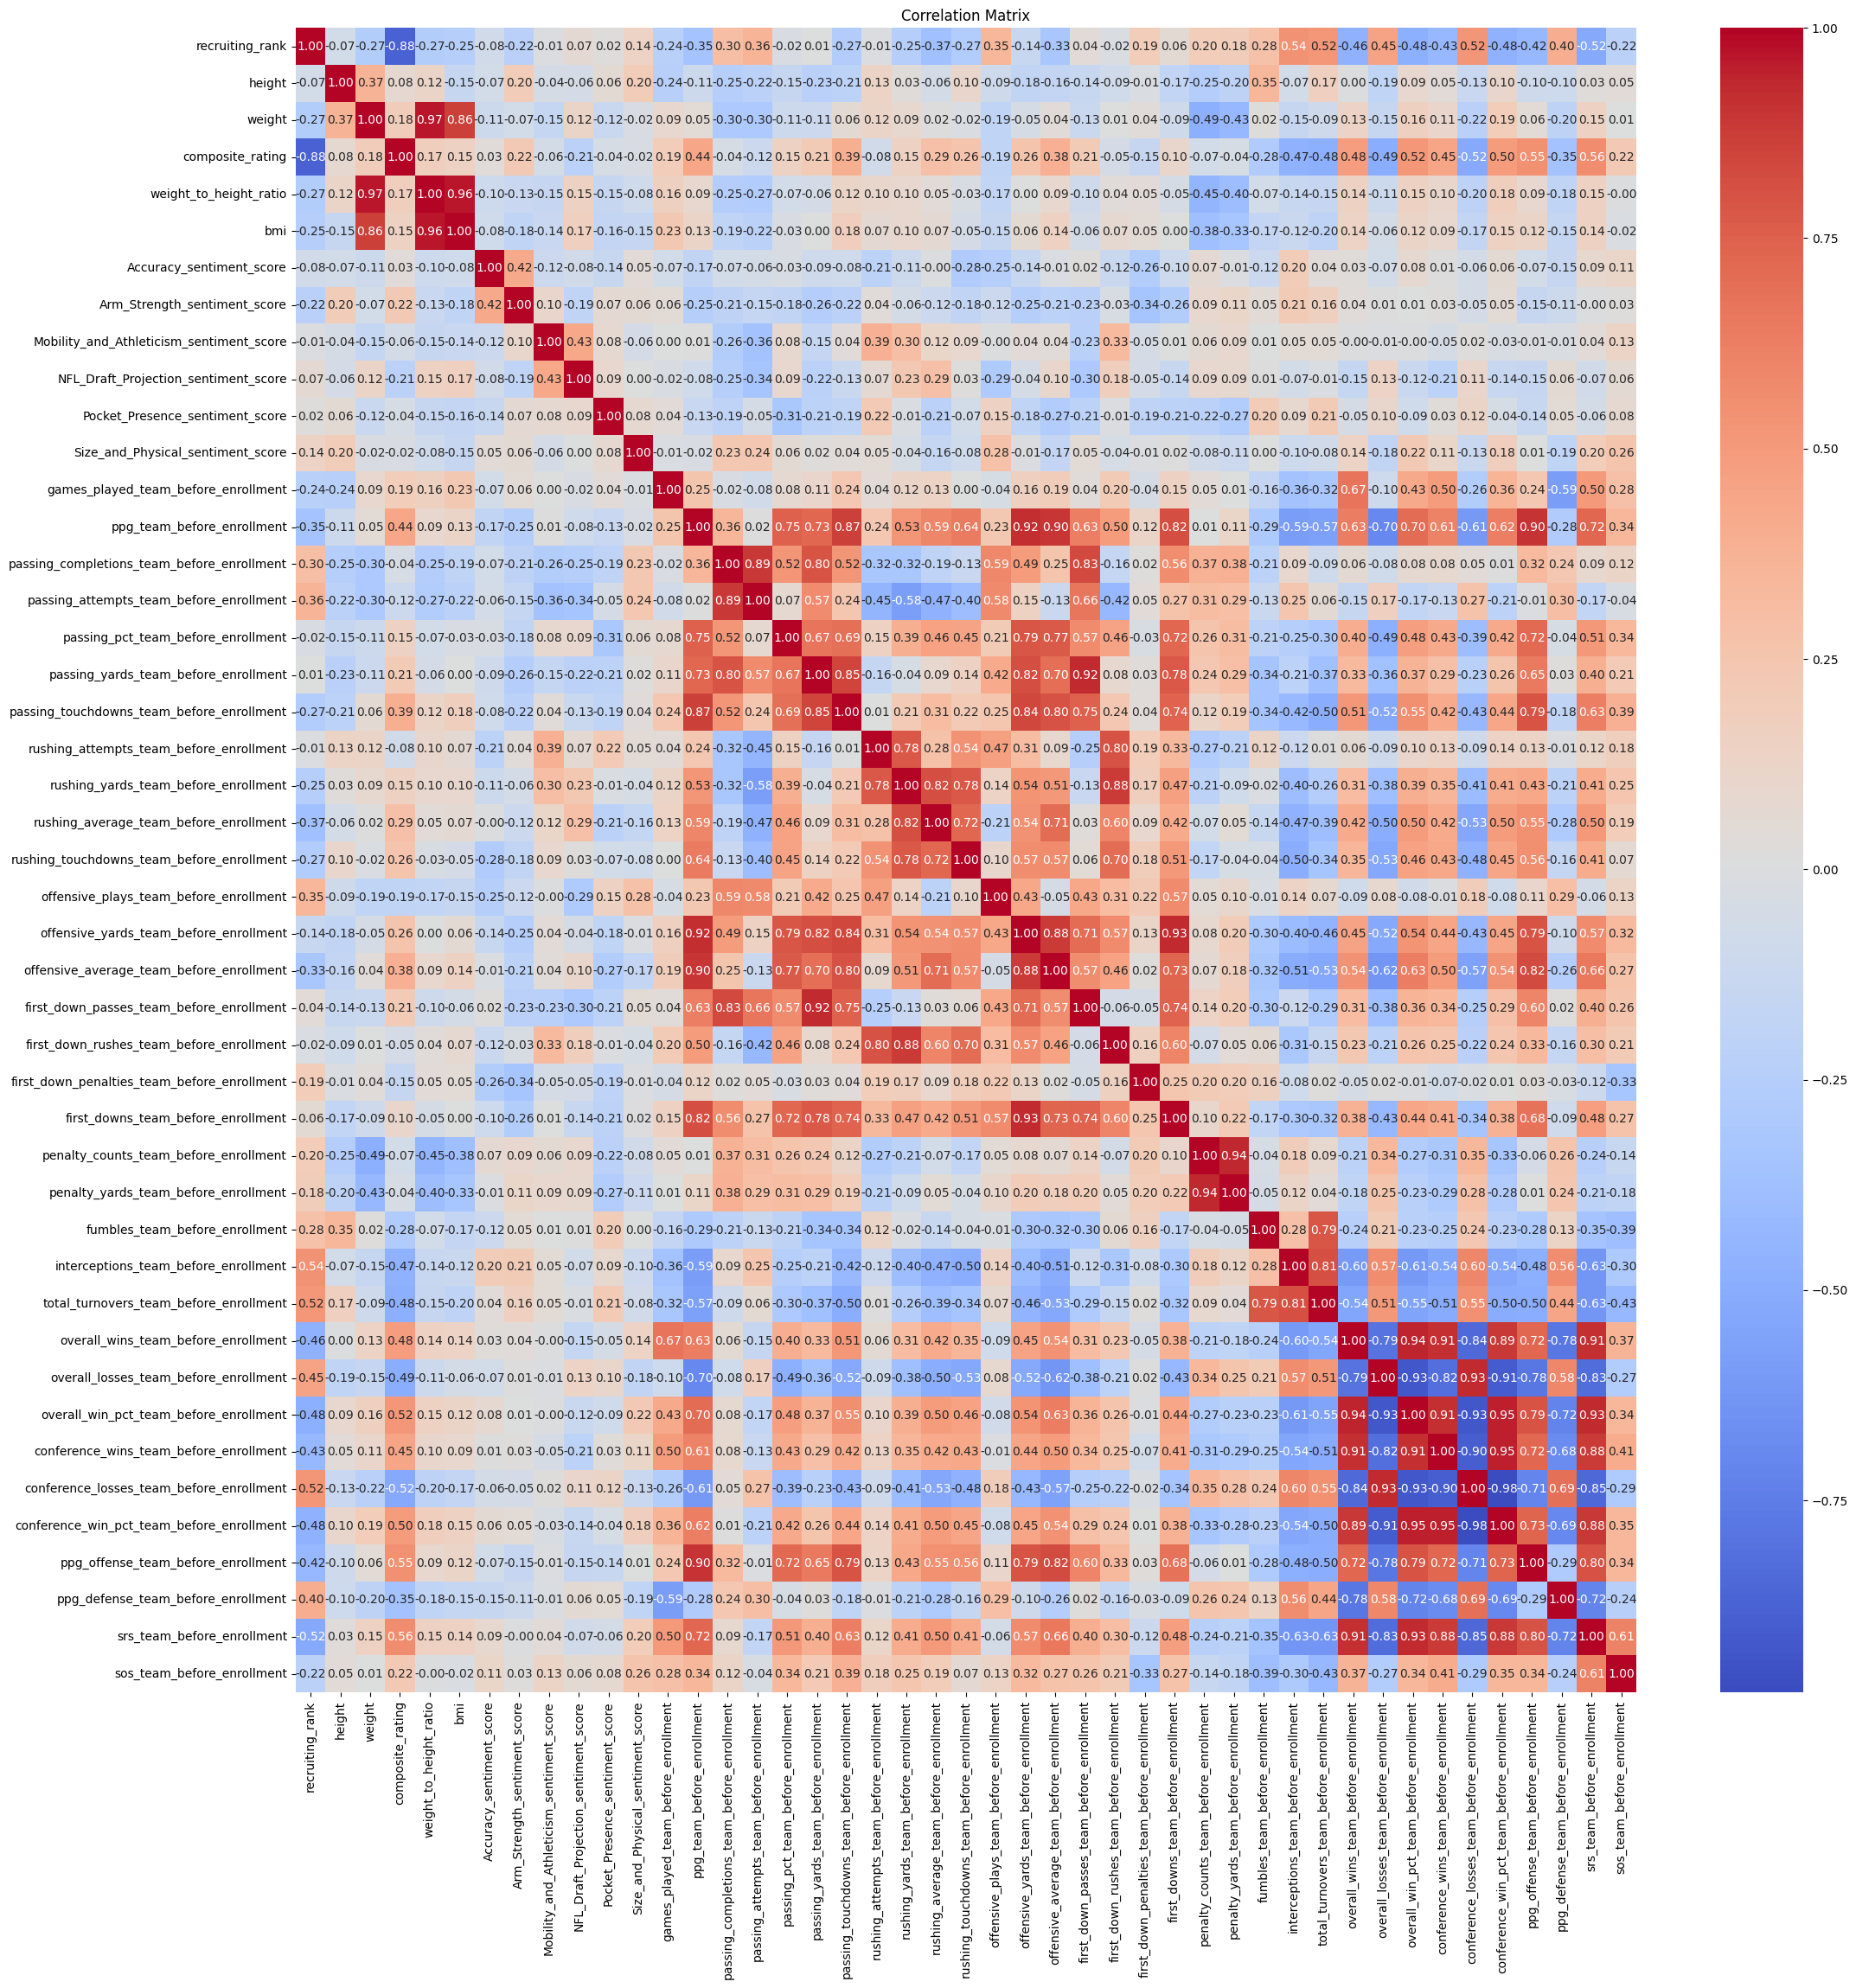

In [93]:
# Examine the correlation between the features and the target variable (boolean features excluded)
correlation_matrix = players[['recruiting_rank',
 'height',
 'weight',
 'composite_rating',
 'weight_to_height_ratio',
 'bmi',
 'Accuracy_sentiment_score',
 'Arm_Strength_sentiment_score',
 'Mobility_and_Athleticism_sentiment_score',
 'NFL_Draft_Projection_sentiment_score',
 'Pocket_Presence_sentiment_score',
 'Size_and_Physical_sentiment_score',
 'games_played_team_before_enrollment',
       'ppg_team_before_enrollment',
       'passing_completions_team_before_enrollment',
       'passing_attempts_team_before_enrollment',
       'passing_pct_team_before_enrollment',
       'passing_yards_team_before_enrollment',
       'passing_touchdowns_team_before_enrollment',
       'rushing_attempts_team_before_enrollment',
       'rushing_yards_team_before_enrollment',
       'rushing_average_team_before_enrollment',
       'rushing_touchdowns_team_before_enrollment',
       'offensive_plays_team_before_enrollment',
       'offensive_yards_team_before_enrollment',
       'offensive_average_team_before_enrollment',
       'first_down_passes_team_before_enrollment',
       'first_down_rushes_team_before_enrollment',
       'first_down_penalties_team_before_enrollment',
       'first_downs_team_before_enrollment',
       'penalty_counts_team_before_enrollment',
       'penalty_yards_team_before_enrollment',
       'fumbles_team_before_enrollment',
       'interceptions_team_before_enrollment',
       'total_turnovers_team_before_enrollment',
       'overall_wins_team_before_enrollment',
       'overall_losses_team_before_enrollment',
       'overall_win_pct_team_before_enrollment',
       'conference_wins_team_before_enrollment',
       'conference_losses_team_before_enrollment',
       'conference_win_pct_team_before_enrollment',
       'ppg_offense_team_before_enrollment',
       'ppg_defense_team_before_enrollment', 
       'srs_team_before_enrollment',
       'sos_team_before_enrollment']].corr()

# Display the correlation matrix
plt.figure(figsize=(25, 25))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

Note: Lots of concerning correlations here. Let's record high correlations (>= 0.8 or <= -0.8) and remove certain predictors accordingly. 

In [94]:
# locate variables with high correlation to each other
correlation_matrix > 0.8

,recruiting_rank,height,weight,composite_rating,weight_to_height_ratio,bmi,Accuracy_sentiment_score,Arm_Strength_sentiment_score,Mobility_and_Athleticism_sentiment_score,NFL_Draft_Projection_sentiment_score,...,overall_wins_team_before_enrollment,overall_losses_team_before_enrollment,overall_win_pct_team_before_enrollment,conference_wins_team_before_enrollment,conference_losses_team_before_enrollment,conference_win_pct_team_before_enrollment,ppg_offense_team_before_enrollment,ppg_defense_team_before_enrollment,srs_team_before_enrollment,sos_team_before_enrollment
recruiting_rank,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
height,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
weight,False,False,True,False,True,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
composite_rating,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
weight_to_height_ratio,False,False,True,False,True,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
bmi,False,False,True,False,True,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
Accuracy_sentiment_score,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
Arm_Strength_sentiment_score,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
Mobility_and_Athleticism_sentiment_score,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
NFL_Draft_Projection_sentiment_score,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [95]:
correlation_matrix[correlation_matrix.abs() > 0.8]

,recruiting_rank,height,weight,composite_rating,weight_to_height_ratio,bmi,Accuracy_sentiment_score,Arm_Strength_sentiment_score,Mobility_and_Athleticism_sentiment_score,NFL_Draft_Projection_sentiment_score,...,overall_wins_team_before_enrollment,overall_losses_team_before_enrollment,overall_win_pct_team_before_enrollment,conference_wins_team_before_enrollment,conference_losses_team_before_enrollment,conference_win_pct_team_before_enrollment,ppg_offense_team_before_enrollment,ppg_defense_team_before_enrollment,srs_team_before_enrollment,sos_team_before_enrollment
recruiting_rank,1.000000,NaN,NaN,-0.881276,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
height,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,NaN,NaN,1.000000,NaN,0.967174,0.861458,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
composite_rating,-0.881276,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight_to_height_ratio,NaN,NaN,0.967174,NaN,1.000000,0.962209,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,NaN,NaN,0.861458,NaN,0.962209,1.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Accuracy_sentiment_score,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Arm_Strength_sentiment_score,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mobility_and_Athleticism_sentiment_score,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NFL_Draft_Projection_sentiment_score,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [96]:
def find_high_correlations(df, threshold=0.8):
    corr = df.corr()
    
    # Get upper triangle only (avoid duplicates + self-correlations)
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    
    # Stack, drop NaNs, filter by threshold
    high_corr = (
        upper.stack()
             .reset_index()
             .rename(columns={"level_0": "var1", "level_1": "var2", 0: "correlation"})
    )
    high_corr = high_corr[high_corr["correlation"].abs() >= threshold]
    high_corr = high_corr.sort_values("correlation", ascending=False)
    
    return high_corr

In [97]:
find_high_correlations(correlation_matrix, threshold=0.8)

,var1,var2,correlation
1705,overall_win_pct_team_before_enrollment,conference_win_pct_team_before_enrollment,0.995547
1750,conference_wins_team_before_enrollment,conference_win_pct_team_before_enrollment,0.993698
1703,overall_win_pct_team_before_enrollment,conference_wins_team_before_enrollment,0.992641
1613,overall_wins_team_before_enrollment,conference_wins_team_before_enrollment,0.992244
1708,overall_win_pct_team_before_enrollment,srs_team_before_enrollment,0.992221
...,...,...,...
1749,conference_wins_team_before_enrollment,conference_losses_team_before_enrollment,-0.984670
1660,overall_losses_team_before_enrollment,conference_win_pct_team_before_enrollment,-0.988014
1657,overall_losses_team_before_enrollment,overall_win_pct_team_before_enrollment,-0.991063
1704,overall_win_pct_team_before_enrollment,conference_losses_team_before_enrollment,-0.992431


Examples of very high correlated variables:

- conference_win_pct_team_before_enrollment
- conference_wins_team_before_enrollment
- conference_losses_team_before_enrollment
- overall_win_pct_team_before_enrollment
- ppg_team_before_enrollment
- first_down_passes_team_before_enrollment

These examples are expected as they affect one another. Being cautious of this, let's move forward with multiple linear regression. 


---
# Multiple Linear Regression

---

Going forward, each section will be the compilation of several models with differing predictor sets and experiments to find the best model.

## **Model 1:**

In [98]:
# Create the predictor variables and the target variable
X = players[['height', 'weight',
       'composite_rating', 'Is_FBS', 'Is_SEC',
       'Is_Big_Ten', 'Is_Big_XII', 'Is_ACC', 'pos_DUAL', 'pos_PRO', 'pos_QB',
       'star_2', 'star_3', 'star_4', 'star_5', 'Is_Top_Five_Ranked',
       'Is_From_East', 'Is_From_West',  'Accuracy_sentiment_score', 'Arm_Strength_sentiment_score',
       'Mobility_and_Athleticism_sentiment_score',
       'Pocket_Presence_sentiment_score', 'Size_and_Physical_sentiment_score', 'passing_pct_team_before_enrollment',
       'passing_yards_team_before_enrollment',
       'passing_touchdowns_team_before_enrollment', 'rushing_average_team_before_enrollment',
       'rushing_touchdowns_team_before_enrollment', 'offensive_yards_team_before_enrollment', 'penalty_counts_team_before_enrollment', 'fumbles_team_before_enrollment',
       'interceptions_team_before_enrollment', 'overall_wins_team_before_enrollment',
       'overall_losses_team_before_enrollment', 'ppg_offense_team_before_enrollment',
       'ppg_defense_team_before_enrollment', 'srs_team_before_enrollment',  'final_ranking_team_AP_top_10_before_enrollment',
       'highest_ranking_team_AP_top_10_before_enrollment']]

y = players['TD/INT_Ratio_player_after_enrollment']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create scaler object to scale the features
scaler = StandardScaler()

# Scale the features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [99]:
# Create linear regression model
model_1 = sm.OLS(y_train, X_train_scaled).fit()

# Print the model summary
print(model_1.summary())

                                          OLS Regression Results                                         
Dep. Variable:     TD/INT_Ratio_player_after_enrollment   R-squared (uncentered):                   0.239
Model:                                              OLS   Adj. R-squared (uncentered):            -24.126
Method:                                   Least Squares   F-statistic:                           0.009793
Date:                                  Thu, 04 Jun 2026   Prob (F-statistic):                        1.00
Time:                                          19:05:08   Log-Likelihood:                         -83.199
No. Observations:                                    33   AIC:                                      230.4
Df Residuals:                                         1   BIC:                                      278.3
Df Model:                                            32                                                  
Covariance Type:                              

Very poor results; let's get the predictions and examine the MSE and RMSE.

In [100]:
# Predict on the test set
y_hat = model_1.predict(X_test_scaled)

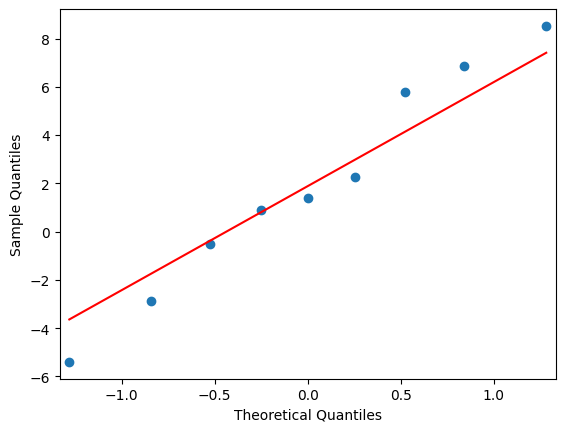

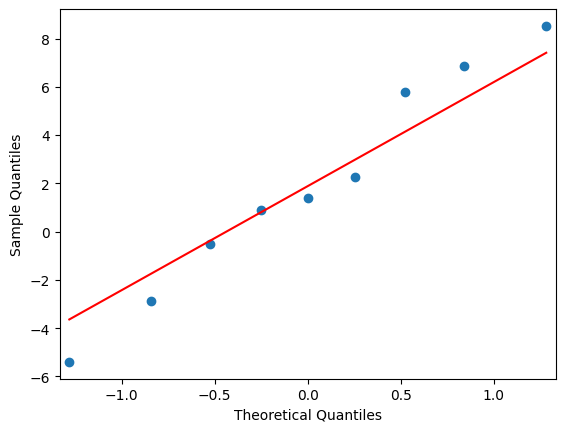

In [101]:
# Look at qq plot
sm.qqplot(y_test - y_hat, line='s')

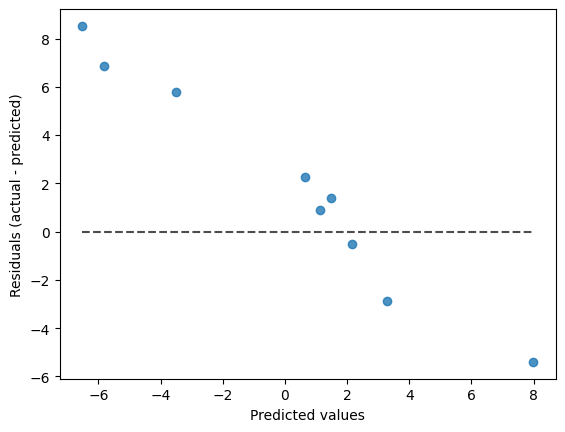

In [102]:
display = PredictionErrorDisplay(y_true = y_test, y_pred = y_hat)
display.plot()
plt.show()

In [103]:
# Get the Mean Squared Error
mse = mean_squared_error(y_test, y_hat)

# Get the Root Mean Squared Error
rmse = np.sqrt(mse)

# Print the results
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')

Mean Squared Error: 22.14040000098972
Root Mean Squared Error: 4.705358647434829


Very bad model; high rmse and mse, negative R^2 adj, negative pattern present in the prediction error plot. The only positive is the normal pattern in the qqplot, meeting the normality assumption.


This means there are a lot of noisy and unimportant features in the model. Let's examine which features to take out of the model.

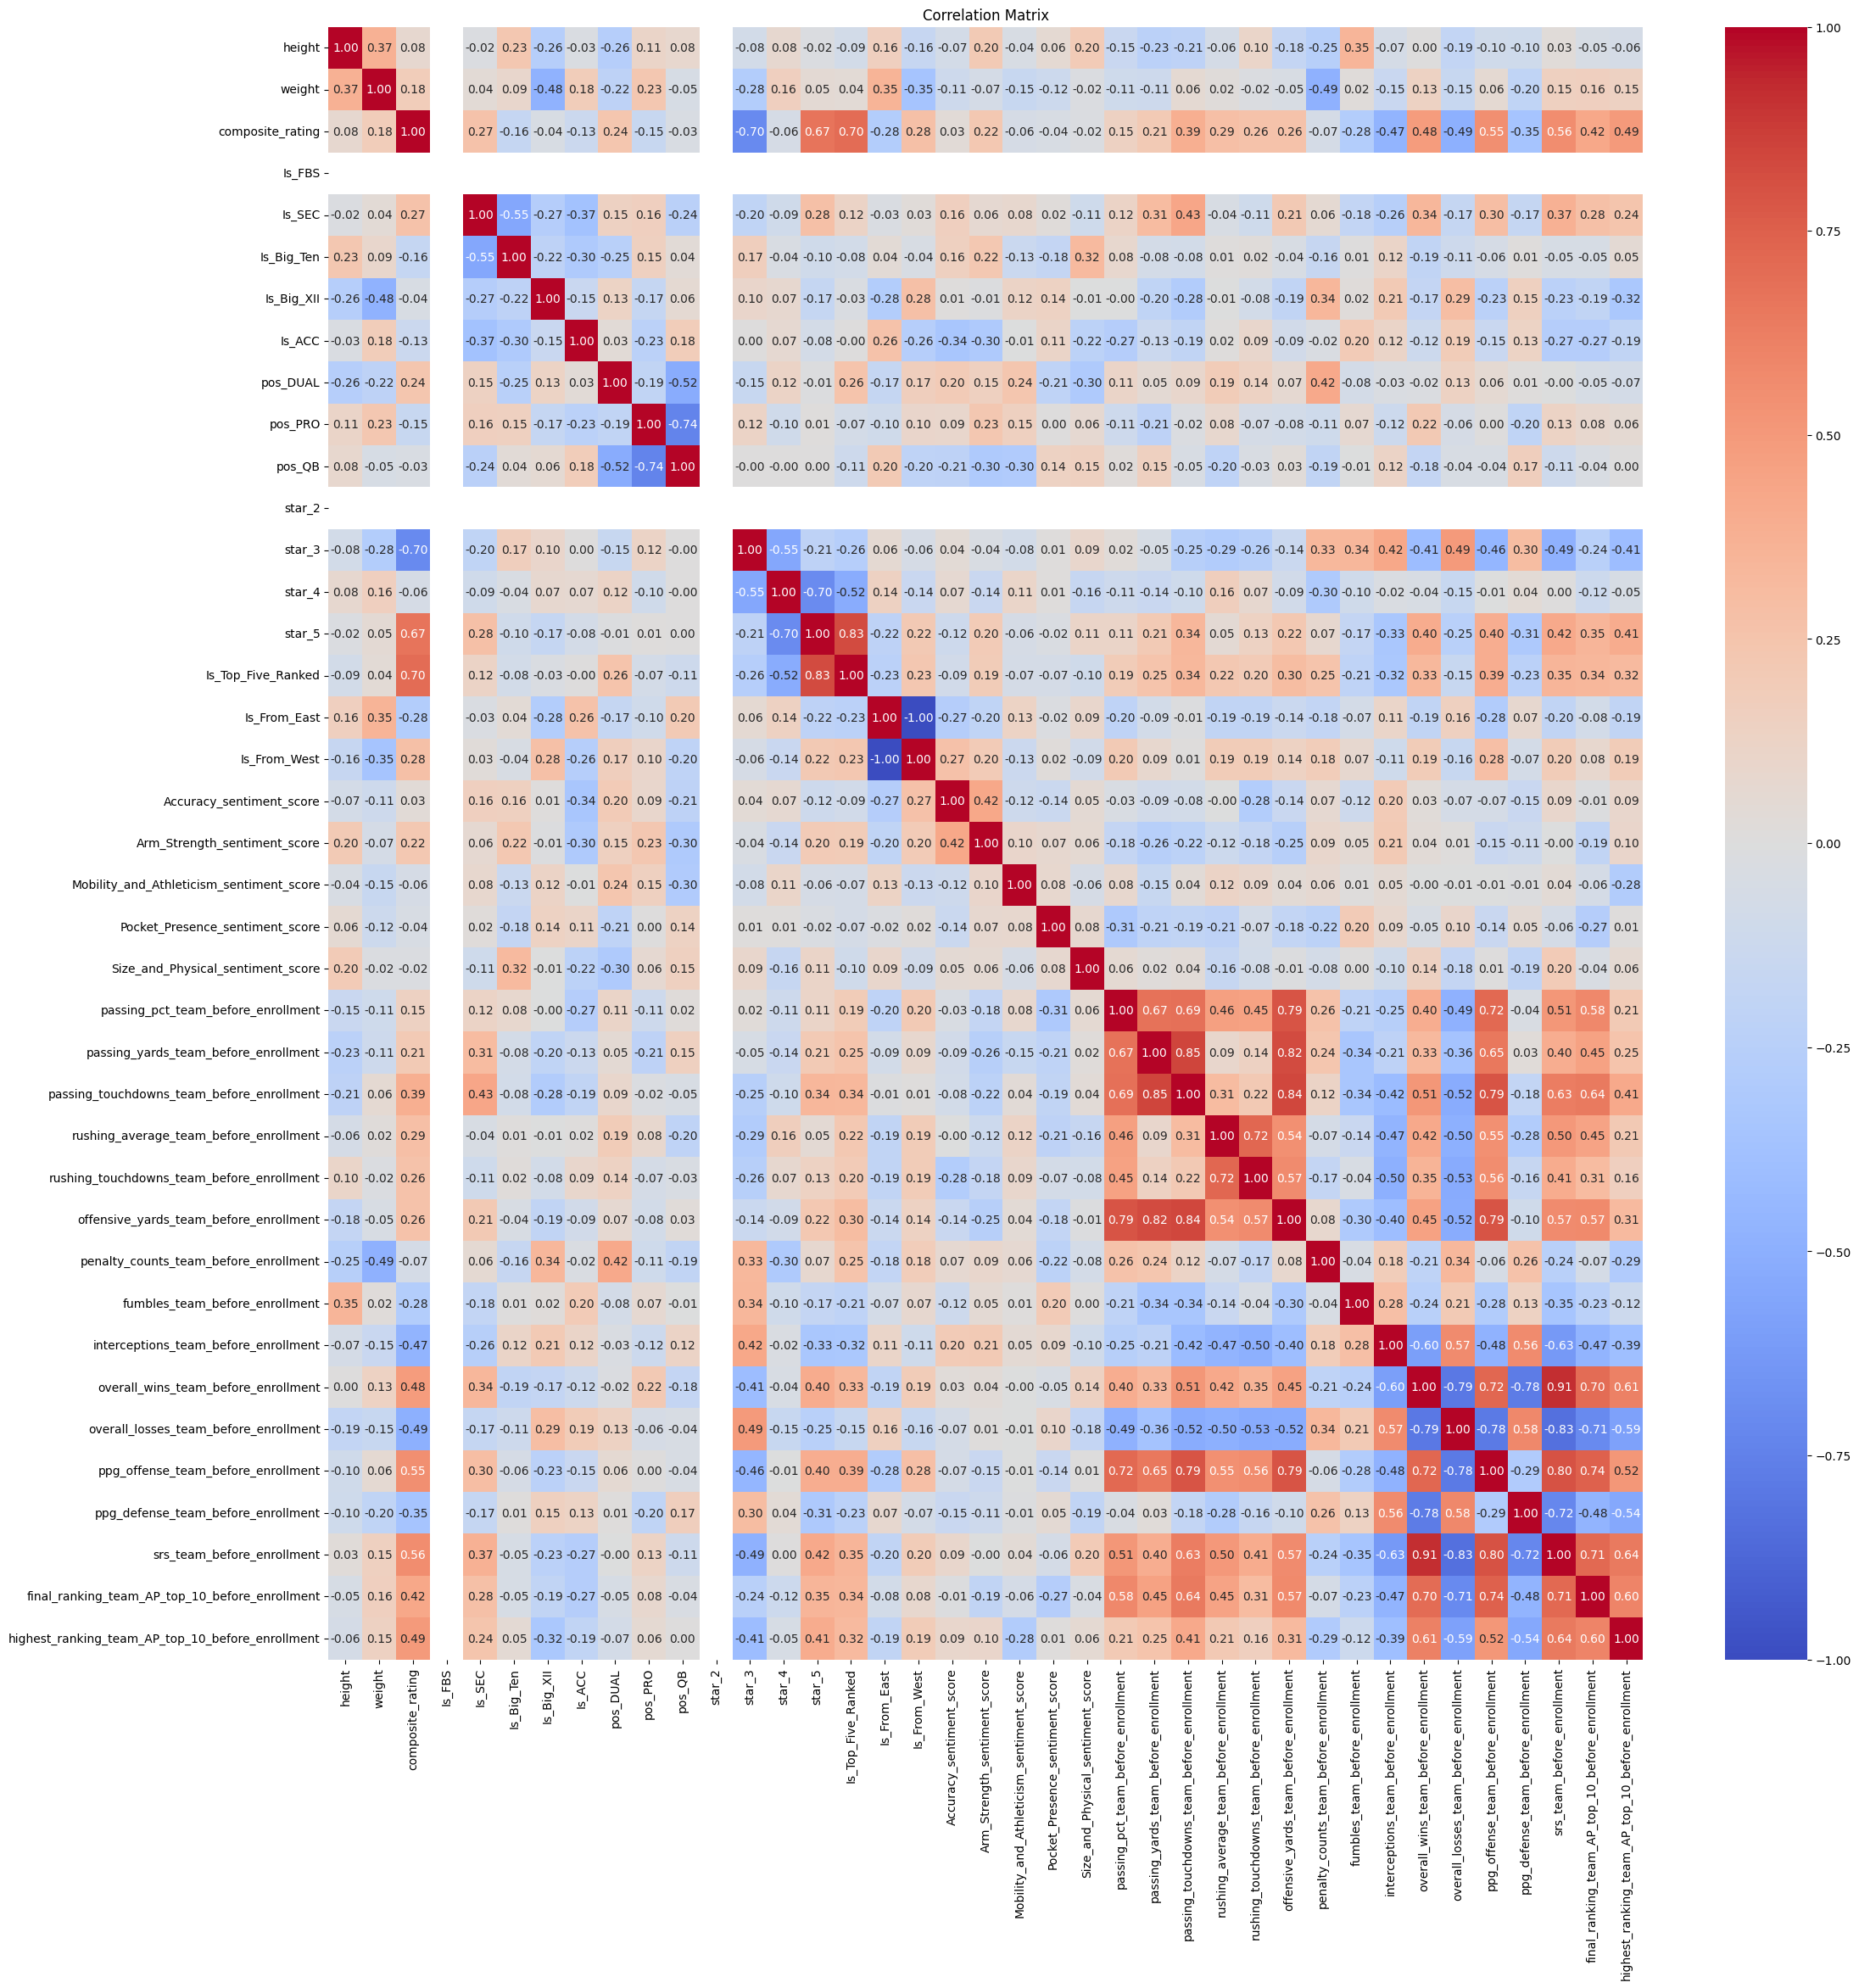

In [104]:
# Examine the correlation between the features
correlation_matrix = X.corr()
# Display the correlation matrix
plt.figure(figsize=(25, 25))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [105]:
X.columns

Index(['height', 'weight', 'composite_rating', 'Is_FBS', 'Is_SEC',
       'Is_Big_Ten', 'Is_Big_XII', 'Is_ACC', 'pos_DUAL', 'pos_PRO', 'pos_QB',
       'star_2', 'star_3', 'star_4', 'star_5', 'Is_Top_Five_Ranked',
       'Is_From_East', 'Is_From_West', 'Accuracy_sentiment_score',
       'Arm_Strength_sentiment_score',
       'Mobility_and_Athleticism_sentiment_score',
       'Pocket_Presence_sentiment_score', 'Size_and_Physical_sentiment_score',
       'passing_pct_team_before_enrollment',
       'passing_yards_team_before_enrollment',
       'passing_touchdowns_team_before_enrollment',
       'rushing_average_team_before_enrollment',
       'rushing_touchdowns_team_before_enrollment',
       'offensive_yards_team_before_enrollment',
       'penalty_counts_team_before_enrollment',
       'fumbles_team_before_enrollment',
       'interceptions_team_before_enrollment',
       'overall_wins_team_before_enrollment',
       'overall_losses_team_before_enrollment',
       'ppg_offense_team_b

For the next model let's remove:

- All Star ranking boolean variables ('star_2', 'star_3', 'star_4', 'star_5')
- 'passing_yards_team_before_enrollment'
- 'passing_pct_team_before_enrollment'
- 'offensive_yards_team_before_enrollment'
- 'srs_team_before_enrollment'
- 'ppg_offense_team_before_enrollment'

In [106]:
X = X.drop(columns=['star_2', 'star_3', 'star_4', 'star_5',
                     'passing_yards_team_before_enrollment','passing_pct_team_before_enrollment',
                     'offensive_yards_team_before_enrollment', 'srs_team_before_enrollment', 'ppg_offense_team_before_enrollment'])

## **Model 2:**

In [107]:
# With the reduced set of features, split the data into training and testing sets again
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale the features again
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create linear regression model
model_2 = sm.OLS(y_train, X_train_scaled).fit()

# Get the summary of the model
print(model_2.summary())

                                          OLS Regression Results                                         
Dep. Variable:     TD/INT_Ratio_player_after_enrollment   R-squared (uncentered):                   0.211
Model:                                              OLS   Adj. R-squared (uncentered):             -3.342
Method:                                   Least Squares   F-statistic:                            0.05928
Date:                                  Thu, 04 Jun 2026   Prob (F-statistic):                        1.00
Time:                                          19:05:11   Log-Likelihood:                         -83.795
No. Observations:                                    33   AIC:                                      221.6
Df Residuals:                                         6   BIC:                                      262.0
Df Model:                                            27                                                  
Covariance Type:                              

In [108]:
# Predict on the test set
y_hat = model_2.predict(X_test_scaled)

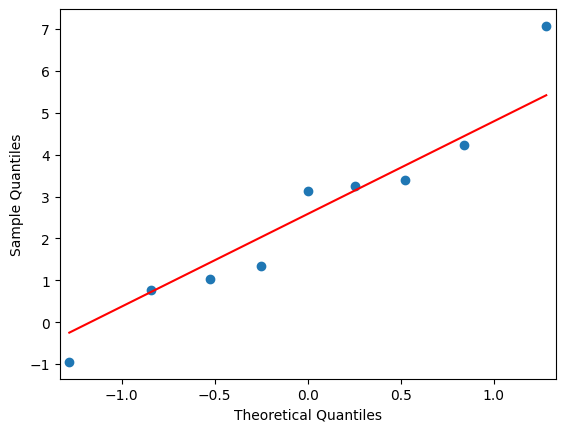

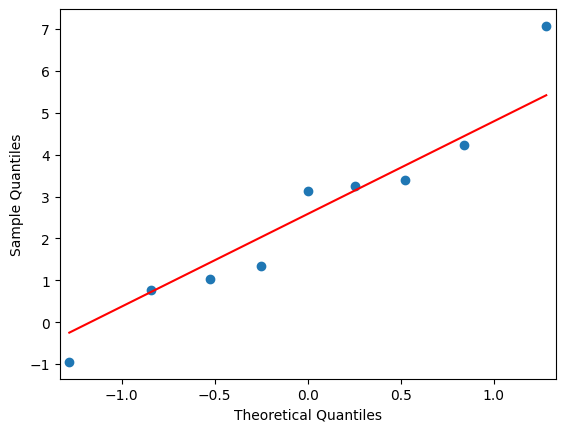

In [109]:
# Look at qq plot
sm.qqplot(y_test - y_hat, line='s')

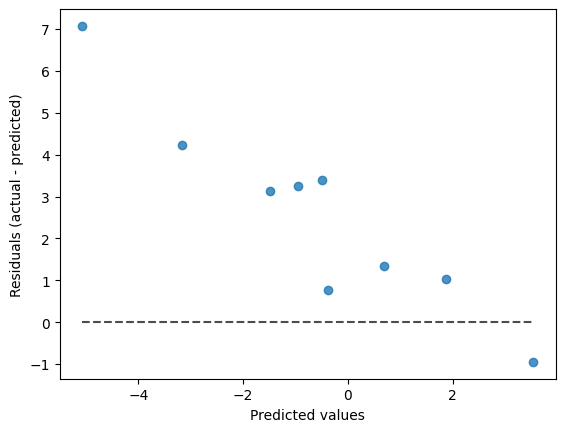

In [113]:
display = PredictionErrorDisplay(y_true = y_test, y_pred = y_hat)
display.plot()
plt.show()

In [114]:
# Get the Mean Squared Error
mse = mean_squared_error(y_test, y_hat)

# Get the Root Mean Squared Error
rmse = np.sqrt(mse)

# Print the results
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')

Mean Squared Error: 11.576458732770144
Root Mean Squared Error: 3.402419540969359


The results are quite a bit better but still suffer from the same issues. Let's examine the VIF.

In [115]:
# Examine the VIF values for the features
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)

                                             feature        VIF
0                                             height   2.619200
1                                             weight   3.018236
2                                   composite_rating   8.666452
3                                             Is_FBS   0.000000
4                                             Is_SEC  25.316387
5                                         Is_Big_Ten  23.250457
6                                         Is_Big_XII   9.792519
7                                             Is_ACC  17.154198
8                                           pos_DUAL        inf
9                                            pos_PRO        inf
10                                            pos_QB        inf
11                                Is_Top_Five_Ranked   5.943255
12                                      Is_From_East        inf
13                                      Is_From_West        inf
14                          Accuracy_sen

C:\Users\austy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\Users\austy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


For model 3 let's remove: 

- 'overall_losses_team_before_enrollment'
- 'Is_ACC'
- 'Is_SEC'
- 'Is_Big_Ten'

In [116]:
# Remove features with high VIF values
X = X.drop(columns=['overall_losses_team_before_enrollment', 'Is_ACC', 'Is_SEC', 'Is_Big_Ten'])

## **Model 3:**

In [117]:
# With the reduced set of features, split the data into training and testing sets again
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale the features again
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create linear regression model
model_3 = sm.OLS(y_train, X_train_scaled).fit()

# Get the summary of the model
print(model_3.summary())

                                          OLS Regression Results                                         
Dep. Variable:     TD/INT_Ratio_player_after_enrollment   R-squared (uncentered):                   0.194
Model:                                              OLS   Adj. R-squared (uncentered):             -1.661
Method:                                   Least Squares   F-statistic:                             0.1045
Date:                                  Thu, 04 Jun 2026   Prob (F-statistic):                        1.00
Time:                                          19:13:06   Log-Likelihood:                         -84.143
No. Observations:                                    33   AIC:                                      214.3
Df Residuals:                                        10   BIC:                                      248.7
Df Model:                                            23                                                  
Covariance Type:                              